In [247]:
##1: import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### New modules from Sklearn.preprocessing
from sklearn.preprocessing import StandardScaler ##to standarize data
from sklearn.neighbors import KNeighborsClassifier
###from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [248]:
##2: read data
##train & test provided no need to use train test split method
df_train = pd.read_csv('/content/train_KNN.csv')
df_test = pd.read_csv('/content/test_KNN.csv')

**TRAIN DATA CLEANING**


In [249]:
##3: import first 10th data
df_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


female are likely to be saved compared to male

there are some NaN -> need imputation

some unnecessary columns( Name, ticket #)-> excluded

Cabin is necessary -> seat location, exit door

Ticket fare more -> hire security, escaping boat provided

In [250]:
### Find and sum up null values in each column
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [251]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [252]:
### Check no. of row (axis=0) and column(axis=1)
df_train.shape

(891, 12)

In [253]:
### compute % of missing data(NaN)
nan_percent =100*(df_train.isnull().sum()/len(df_train))

In [254]:
###Create Function
def missing_percent(df):
  nan_percent = 100 * (df.isnull().sum() / len(df))
  nan_percent = nan_percent[nan_percent > 0].sort_values(ascending=False)
  return nan_percent

In [255]:
###perform sort values
nan_percent = missing_percent(df_train)
nan_percent

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467


In [256]:
###(Optional) find and show data has less than 1% of NaN
nan_percent[nan_percent <1].index

Index(['Embarked'], dtype='object')

In [257]:
### Project those NaN data of corresponding column
df_train[df_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [258]:
### Remove
df_train = df_train.dropna(axis=0, subset='Embarked')
df_train[df_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [259]:
### Imputation: Age with Median
## find median
median= df_train['Age'].median()
median

28.0

In [260]:
##Fill NaN with median
df_train['Age']= df_train['Age'].fillna(median)
## Check sum of NaN of Age
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [261]:
### Remove all NaN cabin
df_train = df_train.drop(['Cabin'],axis=1)


In [262]:
nan_percent = missing_percent(df_train)
nan_percent

,0


**TEST DATA CLEANING**

In [263]:
df_test.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [264]:
###NaN in amount
df_test.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [265]:
###NaN in %
100*(df_test.isnull().sum()/len(df_test))

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [266]:
###Cleaner missing data in %
nan_percent =missing_percent(df_test)
nan_percent

,0
Cabin,78.229665
Age,20.574163
Fare,0.239234


In [267]:
### Remove Fare row
df_test = df_test.dropna(axis =0, subset= 'Fare')

In [268]:
### Drop Cabin
df_test = df_test.drop(['Cabin'], axis=1)

In [269]:
###Checking 2 removals
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          331 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 39.1+ KB


In [270]:
### Imputing Age
## Find median
median = df_test['Age'].median()
median

27.0

In [271]:
## Fill Age with Median
df_test['Age'] = df_test['Age'].fillna(median)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          417 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 39.1+ KB


In [272]:
### Drop unused "Ticket" "Name" "Passenger ID"
df_train.drop(['Name', 'Ticket', 'PassengerId'], axis= 1, inplace=True)
df_test.drop(['Name', 'Ticket', 'PassengerId'], axis= 1, inplace=True)

In [273]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [274]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  417 non-null    int64  
 1   Pclass    417 non-null    int64  
 2   Sex       417 non-null    object 
 3   Age       417 non-null    float64
 4   SibSp     417 non-null    int64  
 5   Parch     417 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  417 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 29.3+ KB


**CLUSTERING**

In [275]:
### TRAIN int -> object
df_train['Survived']= df_train['Survived'].apply(str)
df_train['Pclass']= df_train['Pclass'].apply(str)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    object 
 1   Pclass    889 non-null    object 
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 62.5+ KB


In [276]:
## Divide into 2 categories: numerical and categorical
df_train_num= df_train.select_dtypes(exclude='object')
df_train_obj = df_train.select_dtypes(include='object')

In [277]:
## drop Target Variable
df_train_obj.drop('Survived', axis =1, inplace= True)

In [278]:
## Create dummy variable
## Dummification
df_train_obj = pd.get_dummies(df_train_obj, drop_first = True)

In [279]:
## Final
df_train_final = pd.concat([df_train_num, df_train_obj, df_train['Survived']], axis =1)
df_train_final

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1,0,7.2500,False,True,True,False,True,0
1,38.0,1,0,71.2833,False,False,False,False,False,1
2,26.0,0,0,7.9250,False,True,False,False,True,1
3,35.0,1,0,53.1000,False,False,False,False,True,1
4,35.0,0,0,8.0500,False,True,True,False,True,0
...,...,...,...,...,...,...,...,...,...,...
886,27.0,0,0,13.0000,True,False,True,False,True,0
887,19.0,0,0,30.0000,False,False,False,False,True,1
888,28.0,1,2,23.4500,False,True,False,False,True,0
889,26.0,0,0,30.0000,False,False,True,False,False,1


In [280]:
### TEST int -> object
df_test['Survived']= df_train['Survived'].apply(str)
df_test['Pclass']= df_train['Pclass'].apply(str)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  416 non-null    object 
 1   Pclass    416 non-null    object 
 2   Sex       417 non-null    object 
 3   Age       417 non-null    float64
 4   SibSp     417 non-null    int64  
 5   Parch     417 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  417 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 29.3+ KB


In [281]:
df_test_num = df_test.select_dtypes(exclude='object')
df_test_obj = df_test.select_dtypes(include='object')

In [282]:
df_test_obj.drop(['Survived'], axis =1, inplace= True)

In [283]:
df_test_obj = pd.get_dummies(df_test_obj, drop_first = True)

In [284]:
df_test_final = pd.concat([df_test_num, df_test_obj, df_test['Survived']], axis =1)
df_test_final

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0,0,7.8292,False,True,True,True,False,0
1,47.0,1,0,7.0000,False,False,False,False,True,1
2,62.0,0,0,9.6875,False,True,True,True,False,1
3,27.0,0,0,8.6625,False,False,True,False,True,1
4,22.0,1,1,12.2875,False,True,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...
413,27.0,0,0,8.0500,True,False,True,False,True,0
414,39.0,0,0,108.9000,False,True,False,False,False,1
415,38.5,0,0,7.2500,False,True,True,False,True,0
416,27.0,0,0,8.0500,True,False,True,False,True,1


In [285]:
df_test = df_test.dropna(axis =0, subset= 'Survived')

In [286]:
df_test['Survived'].isnull().sum()

np.int64(0)

In [287]:
## x&y data
X_train = df_train_final.drop('Survived', axis=1)
Y_train = df_train_final['Survived'].astype(int)

# Handle NaN in df_test_final['Survived'] before splitting
df_test_final_cleaned = df_test_final.dropna(subset=['Survived'])

X_test = df_test_final_cleaned.drop('Survived', axis=1)
Y_test = df_test_final_cleaned['Survived'].astype(int)

**STANDARIZATION**

In [288]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [289]:
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

**KNN (0.51)**

In [290]:
knn_model = KNeighborsClassifier(n_neighbors=5) ##less overfit, more underfit
knn_model.fit(scaled_X_train, Y_train)

KNeighborsClassifier()

In [291]:
y_predict = knn_model.predict(scaled_X_test)
pd.DataFrame({'Y_test':Y_test, 'Y_predict':y_predict})

,Y_test,Y_predict
0,0,0
1,1,1
2,1,0
3,1,0
4,0,0
...,...,...
413,0,0
414,1,1
415,0,0
416,1,0


In [292]:
accuracy_knn= accuracy_score(Y_test, y_predict)
print(f"Accuracy of KNN model: {accuracy_knn:.2f}")

Accuracy of KNN model: 0.51


In [293]:
confusion_matrix(Y_test, y_predict)

array([[157,  97],
       [108,  54]])

In [294]:
test_error_rate = []
# for loop to calculate error by using 1-29 (30) K values
for k in range (1,30):
  knn_model = KNeighborsClassifier(n_neighbors=k)
  knn_model.fit(scaled_X_train, Y_train)

  y_predict_test = knn_model.predict(scaled_X_test)

  test_error = 1 - accuracy_score(Y_test, y_predict_test)
  test_error_rate.append(test_error)

In [295]:
test_error_rate

[0.46153846153846156,
 0.4254807692307693,
 0.47115384615384615,
 0.45432692307692313,
 0.49278846153846156,
 0.4567307692307693,
 0.4879807692307693,
 0.4495192307692307,
 0.47596153846153844,
 0.45432692307692313,
 0.45432692307692313,
 0.4471153846153846,
 0.4639423076923077,
 0.45192307692307687,
 0.4639423076923077,
 0.4495192307692307,
 0.45432692307692313,
 0.45192307692307687,
 0.4567307692307693,
 0.43509615384615385,
 0.43990384615384615,
 0.44471153846153844,
 0.44471153846153844,
 0.44471153846153844,
 0.4471153846153846,
 0.44471153846153844,
 0.4471153846153846,
 0.4471153846153846,
 0.45432692307692313]

In [296]:
test_error_rate[11] ## K at 12th

0.4471153846153846

Text(0.5, 0, 'K Value')

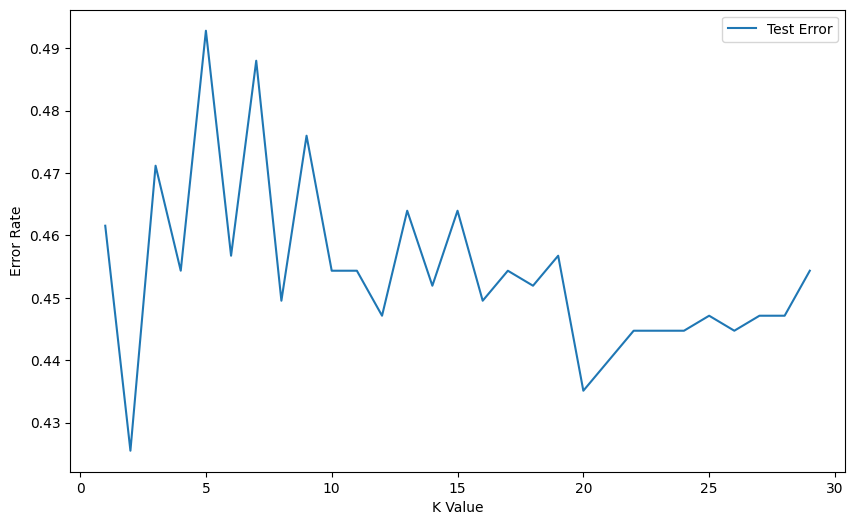

In [297]:
plt.figure(figsize=(10,6))
plt.plot(range(1,30), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

In [298]:
#Final model
scaler = StandardScaler()
knn12 = KNeighborsClassifier(n_neighbors=12)
knn12


KNeighborsClassifier(n_neighbors=12)

In [299]:
test_error_rate = []
# for loop to calculate error by using 1-13 (14) K values
for k in range (1,14):
  knn_model = KNeighborsClassifier(n_neighbors=k)
  knn_model.fit(scaled_X_train, Y_train)

  y_predict_test = knn_model.predict(scaled_X_test)

  test_error = 1 - accuracy_score(Y_test, y_predict_test)
  test_error_rate.append(test_error)

Text(0.5, 0, 'K Value')

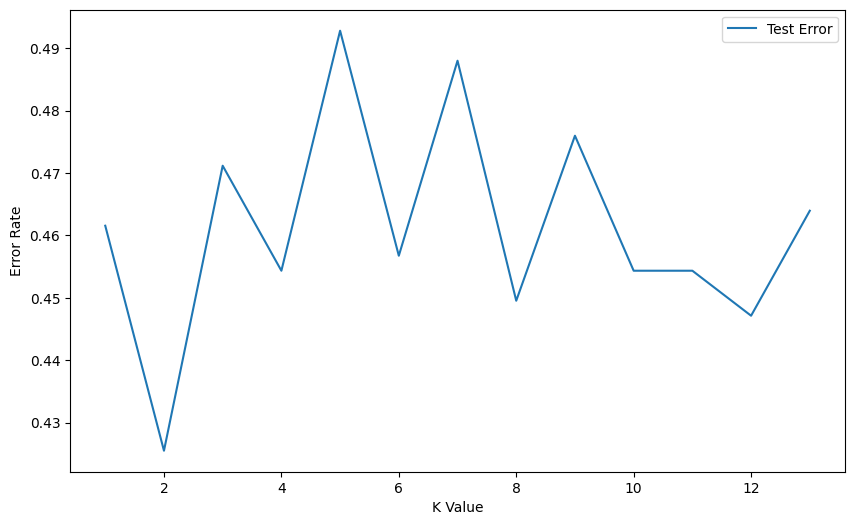

In [300]:
plt.figure(figsize=(10,6))
plt.plot(range(1,14), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

**Logistic Regression (0.58)**

In [301]:
##Replace with actual column names

X_train = df_train[['Age', 'SibSp', 'Parch']]
Y_train = df_train['Survived']

X_test = df_test[['Age', 'SibSp', 'Parch']]
Y_test = df_test['Survived']

In [302]:
##Imputing value using SimpleImputer function from sklearn lib

imputer = SimpleImputer(strategy = 'mean') ## can use median or other strategies
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [303]:
model = LogisticRegression()
model.fit(X_train_imputed, Y_train)

LogisticRegression()

In [304]:
## make prediction on test set
Y_pred = model.predict(X_test_imputed)
Y_prob = model.predict_proba(X_test_imputed)

In [305]:
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy of Logistic Regression model: {accuracy:.2f}")

## Initialize empty list before appending
accuracy_rate =[]
accuracy_rate.append(accuracy)

Accuracy of Logistic Regression model: 0.58


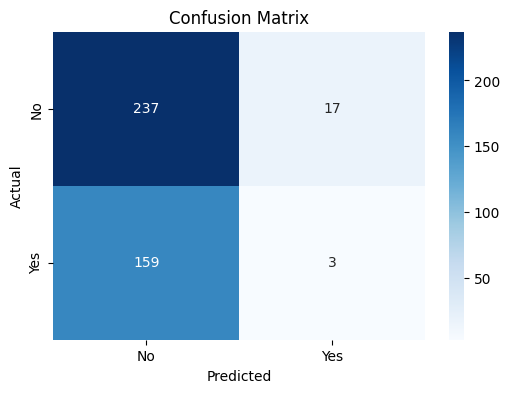

In [306]:
### CONFUSION MATRIX
conf_matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot= True,fmt="d",cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [307]:
###Print all entire instead individual
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.93      0.73       254
           1       0.15      0.02      0.03       162

    accuracy                           0.58       416
   macro avg       0.37      0.48      0.38       416
weighted avg       0.42      0.58      0.46       416



**Decision Tree (0.50)**

In [308]:
dt_model = DecisionTreeClassifier( random_state=42)
dt_model.fit(X_train_imputed, Y_train)

DecisionTreeClassifier(random_state=42)

In [309]:
Y_pred_dt = dt_model.predict(X_test_imputed)

In [310]:
accuracy_dt = accuracy_score(Y_test, Y_pred_dt)
print(f"Accuracy of Decision Tree model: {accuracy_dt:.2f}")

Accuracy of Decision Tree model: 0.50


In [311]:
accuracy_rate.append(accuracy_dt)

In [312]:
print("Classification Report:")
print(classification_report(Y_test, Y_pred_dt))

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       254
           1       0.34      0.32      0.33       162

    accuracy                           0.50       416
   macro avg       0.46      0.46      0.46       416
weighted avg       0.49      0.50      0.49       416



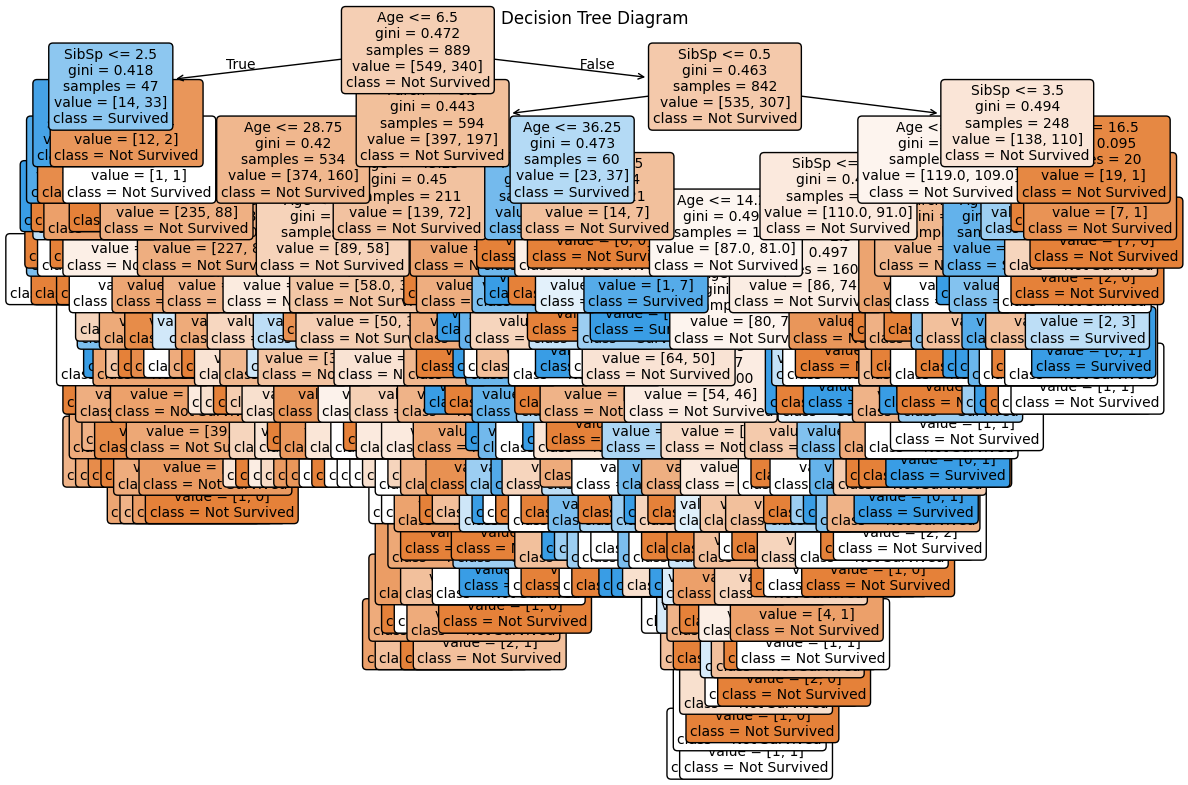

In [313]:
plt.figure(figsize=(12,8))
features = ['Age', 'SibSp', 'Parch']
plot_tree(
    dt_model,
    feature_names = features,
    class_names = ["Not Survived", "Survived"],
    filled = True,
    rounded = True,
    fontsize = 10
)
plt.title("Decision Tree Diagram")
plt.tight_layout() # Added to prevent title overlap
plt.show()